# NYISO Solar Forecasting: Advanced Models

## Purpose

## Research Context

## Questions to Consider

## Imports and Configuration

In [2]:
from pathlib import Path
from datetime import datetime
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from autogluon.tabular import TabularPredictor

warnings.filterwarnings("ignore")
random_state = 42

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

C:\Users\sumai\Documents\ML_NYISOSolarForecasting\.venv-nyiso-pc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# repo_root = Path.home() / "Documents" / "Coding" / "ML_NYISOSolarForecast"
repo_root = Path(r"C:\Users\sumai\Documents\ML_NYISOSolarForecasting")

data_root = repo_root / "data"
processed_dir = data_root / "processed"

model_ready_in = processed_dir / "04_system_model_ready_data.csv"

split_date = pd.Timestamp("2024-07-01 00:00:00+00:00")
validation_start = pd.Timestamp("2024-01-01 00:00:00+00:00")

## Load Dataset

In [4]:
df_model = pd.read_csv(model_ready_in, low_memory=False)

df_model.columns = (
    df_model.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

df_model["time_stamp"] = pd.to_datetime(df_model["time_stamp"], utc=True, errors="coerce")
df_model["time_local"] = df_model["time_stamp"].dt.tz_convert("America/New_York")

print("Shape:", df_model.shape)
print("Time Range:", df_model["time_stamp"].min(), "to", df_model["time_stamp"].max())
print("Columns:")
print(df_model.columns.tolist())

Shape: (41455, 30)
Time Range: 2020-11-17 05:00:00+00:00 to 2025-09-19 03:00:00+00:00
Columns:
['time_stamp', 'time_local', 'zone_name', 'dataset_split', 'actual_mw', 'forecast_mw', 'forecast_error_mw', 'temperature_2m', 'surface_pressure', 'cloud_cover', 'windspeed_10m', 'shortwave_radiation', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofyear_sin', 'forecast_x_hour_sin', 'forecast_x_hour_cos', 'shortwave_x_cloud', 'shortwave_x_temp', 'forecast_roll_mean_3', 'shortwave_roll_mean_3', 'forecast_roll_mean_24', 'shortwave_roll_mean_24', 'forecast_diff_1', 'shortwave_diff_1', 'shortwave_ramp_abs', 'is_morning_ramp', 'is_midday']


## Main Features and Time Context

In [5]:
target = "forecast_error_mw"

required_cols = [
    "time_stamp",
    "time_local",
    "zone_name",
    "dataset_split",
    "actual_mw",
    "forecast_mw",
    "forecast_error_mw",
]

missing_required = [c for c in required_cols if c not in df_model.columns]
if missing_required:
    raise ValueError(f"Missing Necessary Columns in Dataset: {missing_required}")

df_model["hour_local"] = df_model["time_local"].dt.hour
df_model["month_local"] = df_model["time_local"].dt.month
df_model["dayofyear_local"] = df_model["time_local"].dt.dayofyear
df_model["is_daylight"] = (df_model["shortwave_radiation"] > 0).astype(int)

feature_cols = [c for c in df_model.columns if c not in required_cols + [
    "hour_local",
    "month_local",
    "dayofyear_local",
    "is_daylight",
]]

if "forecast_mw" not in feature_cols:
    feature_cols = ["forecast_mw"] + feature_cols

print("\nTarget:", target)
print("Number of Features:", len(feature_cols))
print("Feature Columns:")
print(". . .")
print(feature_cols)


Target: forecast_error_mw
Number of Features: 24
Feature Columns:
. . .
['forecast_mw', 'temperature_2m', 'surface_pressure', 'cloud_cover', 'windspeed_10m', 'shortwave_radiation', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofyear_sin', 'forecast_x_hour_sin', 'forecast_x_hour_cos', 'shortwave_x_cloud', 'shortwave_x_temp', 'forecast_roll_mean_3', 'shortwave_roll_mean_3', 'forecast_roll_mean_24', 'shortwave_roll_mean_24', 'forecast_diff_1', 'shortwave_diff_1', 'shortwave_ramp_abs', 'is_morning_ramp', 'is_midday']


## Train, Validation, and Test Splits

In [6]:
train_end = df_model.loc[df_model["dataset_split"].eq("train"), "time_stamp"].max()
test_start = df_model.loc[df_model["dataset_split"].eq("test"), "time_stamp"].min()

X = df_model[feature_cols].copy()
y = df_model[target].copy()

train_mask = (
    df_model["dataset_split"].eq("train")
    & y.notna()
)

test_mask = (
    df_model["dataset_split"].eq("test")
    & df_model[target].notna()
    & df_model["actual_mw"].notna()
    & df_model["forecast_mw"].notna()
)

subtrain_mask = (
    df_model["dataset_split"].eq("train")
    & df_model["time_stamp"].lt(validation_start)
    & df_model[target].notna()
)

valid_mask = (
    df_model["dataset_split"].eq("train")
    & df_model["time_stamp"].ge(validation_start)
    & df_model[target].notna()
    & df_model["actual_mw"].notna()
    & df_model["forecast_mw"].notna()
)

train_df = df_model.loc[train_mask].copy()
test_df = df_model.loc[test_mask].copy()
subtrain_df = df_model.loc[subtrain_mask].copy()
valid_df = df_model.loc[valid_mask].copy()

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()
X_subtrain = subtrain_df[feature_cols].copy()
X_valid = valid_df[feature_cols].copy()

y_train = train_df[target].copy()
y_test = test_df[target].copy()
y_subtrain = subtrain_df[target].copy()
y_valid = valid_df[target].copy()

baseline_actual_test = test_df["actual_mw"].copy()
baseline_forecast_test = test_df["forecast_mw"].copy()

baseline_actual_valid = valid_df["actual_mw"].copy()
baseline_forecast_valid = valid_df["forecast_mw"].copy()

daylight_test_mask = test_df["is_daylight"] == 1
daylight_valid_mask = valid_df["is_daylight"] == 1

assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0] == y_test.shape[0]
assert X_subtrain.shape[0] == y_subtrain.shape[0]
assert X_valid.shape[0] == y_valid.shape[0]

## Median Imputation

In [7]:
imputer = SimpleImputer(strategy="median")

X_subtrain_imp = pd.DataFrame(
    imputer.fit_transform(X_subtrain),
    columns=feature_cols,
    index=X_subtrain.index,
)

X_valid_imp = pd.DataFrame(
    imputer.transform(X_valid),
    columns=feature_cols,
    index=X_valid.index,
)

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index,
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=feature_cols,
    index=X_test.index,
)

## Evaluation Metrics

In [8]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def evaluate_forecasts(actual, forecast):
    return {
        "MAE": mean_absolute_error(actual, forecast),
        "RMSE": rmse(actual, forecast),
    }


def evaluate_daylight_forecasts(actual, forecast, daylight_mask):
    return {
        "Daylight_MAE": mean_absolute_error(actual.loc[daylight_mask], forecast.loc[daylight_mask]),
        "Daylight_RMSE": rmse(actual.loc[daylight_mask], forecast.loc[daylight_mask]),
    }


def summarize_model(name, actual, forecast, daylight_mask):
    out = {"Model": name}
    out.update(evaluate_forecasts(actual, forecast))
    out.update(evaluate_daylight_forecasts(actual, forecast, daylight_mask))
    return out


def apply_physical_bounds(forecast_series):
    return pd.Series(forecast_series, index=forecast_series.index).clip(lower=0.0)


def build_prediction_frame(model_name, eval_df, corrected_forecast):
    pred_df = eval_df[[
        "time_stamp",
        "time_local",
        "actual_mw",
        "forecast_mw",
        "hour_local",
        "month_local",
        "is_daylight",
    ]].copy()

    pred_df["model_name"] = model_name
    pred_df["corrected_forecast_mw"] = apply_physical_bounds(corrected_forecast)
    pred_df["baseline_error_mw"] = pred_df["actual_mw"] - pred_df["forecast_mw"]
    pred_df["model_error_mw"] = pred_df["actual_mw"] - pred_df["corrected_forecast_mw"]
    pred_df["baseline_abs_error_mw"] = pred_df["baseline_error_mw"].abs()
    pred_df["model_abs_error_mw"] = pred_df["model_error_mw"].abs()

    return pred_df


def add_improvement_columns(results_df, baseline_name="NYISO Baseline"):
    baseline_mae = results_df.loc[results_df["Model"] == baseline_name, "MAE"].iloc[0]
    baseline_rmse = results_df.loc[results_df["Model"] == baseline_name, "RMSE"].iloc[0]
    baseline_daylight_mae = results_df.loc[results_df["Model"] == baseline_name, "Daylight_MAE"].iloc[0]
    baseline_daylight_rmse = results_df.loc[results_df["Model"] == baseline_name, "Daylight_RMSE"].iloc[0]

    results_df["MAE_Improvement_vs_NYISO"] = baseline_mae - results_df["MAE"]
    results_df["RMSE_Improvement_vs_NYISO"] = baseline_rmse - results_df["RMSE"]
    results_df["Daylight_MAE_Improvement_vs_NYISO"] = baseline_daylight_mae - results_df["Daylight_MAE"]
    results_df["Daylight_RMSE_Improvement_vs_NYISO"] = baseline_daylight_rmse - results_df["Daylight_RMSE"]

    return results_df

In [9]:
def fit_month_hour_residual_climatology(fit_df):
    month_hour_map = fit_df.groupby(["month_local", "hour_local"])[target].mean()
    hour_map = fit_df.groupby("hour_local")[target].mean()
    global_mean = fit_df[target].mean()
    return month_hour_map, hour_map, global_mean


def predict_month_hour_residual_climatology(eval_df, month_hour_map, hour_map, global_mean):
    pred_residual = []
    for month_val, hour_val in zip(eval_df["month_local"], eval_df["hour_local"]):
        if (month_val, hour_val) in month_hour_map.index:
            pred_residual.append(month_hour_map.loc[(month_val, hour_val)])
        elif hour_val in hour_map.index:
            pred_residual.append(hour_map.loc[hour_val])
        else:
            pred_residual.append(global_mean)

    pred_residual = pd.Series(pred_residual, index=eval_df.index)
    return eval_df["forecast_mw"] + pred_residual

In [10]:
def fit_predict_residual_model(model, X_fit, y_fit, X_eval, eval_forecast):
    model.fit(X_fit, y_fit)
    pred_residual = pd.Series(model.predict(X_eval), index=X_eval.index)
    corrected_forecast = apply_physical_bounds(eval_forecast + pred_residual)
    return corrected_forecast, pred_residual


def fit_predict_sarimax(y_fit, exog_fit, exog_eval, eval_forecast, order=(1, 0, 1), seasonal_order=(1, 0, 1, 24)):
    sarimax_model = SARIMAX(
        endog=y_fit,
        exog=exog_fit,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )

    sarimax_result = sarimax_model.fit(disp=False)
    pred_residual = sarimax_result.forecast(steps=len(exog_eval), exog=exog_eval)
    pred_residual = pd.Series(pred_residual, index=exog_eval.index)
    corrected_forecast = apply_physical_bounds(eval_forecast + pred_residual)

    return corrected_forecast, pred_residual, sarimax_result

## Baselines and Reference Models

In [11]:
prediction_frames_valid = {}
prediction_frames_test = {}
validation_rows = []
test_rows = []

nyiso_valid_forecast = apply_physical_bounds(valid_df["forecast_mw"].copy())
nyiso_test_forecast = apply_physical_bounds(test_df["forecast_mw"].copy())

validation_rows.append(
    summarize_model("NYISO Baseline", baseline_actual_valid, nyiso_valid_forecast, daylight_valid_mask)
)
test_rows.append(
    summarize_model("NYISO Baseline", baseline_actual_test, nyiso_test_forecast, daylight_test_mask)
)

prediction_frames_valid["NYISO Baseline"] = build_prediction_frame("NYISO Baseline", valid_df, nyiso_valid_forecast)
prediction_frames_test["NYISO Baseline"] = build_prediction_frame("NYISO Baseline", test_df, nyiso_test_forecast)

month_hour_map_subtrain, hour_map_subtrain, global_mean_subtrain = fit_month_hour_residual_climatology(subtrain_df)
month_hour_map_train, hour_map_train, global_mean_train = fit_month_hour_residual_climatology(train_df)

month_hour_valid_forecast = apply_physical_bounds(
    predict_month_hour_residual_climatology(valid_df, month_hour_map_subtrain, hour_map_subtrain, global_mean_subtrain)
)
month_hour_test_forecast = apply_physical_bounds(
    predict_month_hour_residual_climatology(test_df, month_hour_map_train, hour_map_train, global_mean_train)
)

validation_rows.append(
    summarize_model("Month-Hour Residual Climatology", baseline_actual_valid, month_hour_valid_forecast, daylight_valid_mask)
)
test_rows.append(
    summarize_model("Month-Hour Residual Climatology", baseline_actual_test, month_hour_test_forecast, daylight_test_mask)
)

prediction_frames_valid["Month-Hour Residual Climatology"] = build_prediction_frame(
    "Month-Hour Residual Climatology", valid_df, month_hour_valid_forecast
)
prediction_frames_test["Month-Hour Residual Climatology"] = build_prediction_frame(
    "Month-Hour Residual Climatology", test_df, month_hour_test_forecast
)

## Advanced Models

### LightGBM

In [12]:
lgbm_model_valid = LGBMRegressor(
    objective="regression",
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=random_state,
)

lgbm_valid_forecast, lgbm_valid_residual = fit_predict_residual_model(
    lgbm_model_valid,
    X_subtrain_imp,
    y_subtrain,
    X_valid_imp,
    valid_df["forecast_mw"],
)

lgbm_model_test = LGBMRegressor(
    objective="regression",
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=random_state,
)

lgbm_test_forecast, lgbm_test_residual = fit_predict_residual_model(
    lgbm_model_test,
    X_train_imp,
    y_train,
    X_test_imp,
    test_df["forecast_mw"],
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002770 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4500
[LightGBM] [Info] Number of data points in the train set: 26630, number of used features: 24
[LightGBM] [Info] Start training from score -0.276261
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002144 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4499
[LightGBM] [Info] Number of data points in the train set: 30921, number of used features: 24
[LightGBM] [Info] Start training from score 2.165826


In [13]:
validation_rows.append(
    summarize_model("LightGBM Residual Model", baseline_actual_valid, lgbm_valid_forecast, daylight_valid_mask)
)
test_rows.append(
    summarize_model("LightGBM Residual Model", baseline_actual_test, lgbm_test_forecast, daylight_test_mask)
)

prediction_frames_valid["LightGBM Residual Model"] = build_prediction_frame(
    "LightGBM Residual Model", valid_df, lgbm_valid_forecast
)
prediction_frames_test["LightGBM Residual Model"] = build_prediction_frame(
    "LightGBM Residual Model", test_df, lgbm_test_forecast
)

### XG Boost

In [14]:
xgb_model_valid = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=random_state,
    n_jobs=-1,
)

xgb_valid_forecast, xgb_valid_residual = fit_predict_residual_model(
    xgb_model_valid,
    X_subtrain_imp,
    y_subtrain,
    X_valid_imp,
    valid_df["forecast_mw"],
)

xgb_model_test = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=random_state,
    n_jobs=-1,
)

xgb_test_forecast, xgb_test_residual = fit_predict_residual_model(
    xgb_model_test,
    X_train_imp,
    y_train,
    X_test_imp,
    test_df["forecast_mw"],
)

In [15]:
validation_rows.append(
    summarize_model("XGBoost Residual Model", baseline_actual_valid, xgb_valid_forecast, daylight_valid_mask)
)
test_rows.append(
    summarize_model("XGBoost Residual Model", baseline_actual_test, xgb_test_forecast, daylight_test_mask)
)

prediction_frames_valid["XGBoost Residual Model"] = build_prediction_frame(
    "XGBoost Residual Model", valid_df, xgb_valid_forecast
)
prediction_frames_test["XGBoost Residual Model"] = build_prediction_frame(
    "XGBoost Residual Model", test_df, xgb_test_forecast
)

### Cat Boost

In [16]:
cat_model_valid = CatBoostRegressor(
    loss_function="RMSE",
    iterations=1200,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3.0,
    random_seed=random_state,
    verbose=False,
)

cat_valid_forecast, cat_valid_residual = fit_predict_residual_model(
    cat_model_valid,
    X_subtrain_imp,
    y_subtrain,
    X_valid_imp,
    valid_df["forecast_mw"],
)

cat_model_test = CatBoostRegressor(
    loss_function="RMSE",
    iterations=1200,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3.0,
    random_seed=random_state,
    verbose=False,
)

cat_test_forecast, cat_test_residual = fit_predict_residual_model(
    cat_model_test,
    X_train_imp,
    y_train,
    X_test_imp,
    test_df["forecast_mw"],
)

In [17]:
validation_rows.append(
    summarize_model("CatBoost Residual Model", baseline_actual_valid, cat_valid_forecast, daylight_valid_mask)
)
test_rows.append(
    summarize_model("CatBoost Residual Model", baseline_actual_test, cat_test_forecast, daylight_test_mask)
)

prediction_frames_valid["CatBoost Residual Model"] = build_prediction_frame(
    "CatBoost Residual Model", valid_df, cat_valid_forecast
)
prediction_frames_test["CatBoost Residual Model"] = build_prediction_frame(
    "CatBoost Residual Model", test_df, cat_test_forecast
)

### Random Forest

In [18]:
rf_model_valid = RandomForestRegressor(
    n_estimators=500,
    max_depth=14,
    min_samples_leaf=2,
    random_state=random_state,
    n_jobs=-1,
)

rf_valid_forecast, rf_valid_residual = fit_predict_residual_model(
    rf_model_valid,
    X_subtrain_imp,
    y_subtrain,
    X_valid_imp,
    valid_df["forecast_mw"],
)

rf_model_test = RandomForestRegressor(
    n_estimators=500,
    max_depth=14,
    min_samples_leaf=2,
    random_state=random_state,
    n_jobs=-1,
)

rf_test_forecast, rf_test_residual = fit_predict_residual_model(
    rf_model_test,
    X_train_imp,
    y_train,
    X_test_imp,
    test_df["forecast_mw"],
)

In [19]:
validation_rows.append(
    summarize_model("Random Forest Residual Model", baseline_actual_valid, rf_valid_forecast, daylight_valid_mask)
)
test_rows.append(
    summarize_model("Random Forest Residual Model", baseline_actual_test, rf_test_forecast, daylight_test_mask)
)

prediction_frames_valid["Random Forest Residual Model"] = build_prediction_frame(
    "Random Forest Residual Model", valid_df, rf_valid_forecast
)
prediction_frames_test["Random Forest Residual Model"] = build_prediction_frame(
    "Random Forest Residual Model", test_df, rf_test_forecast
)

### HistGradientBoostingRegressor

In [20]:
hgb_model_valid = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.03,
    max_iter=5000,
    max_depth=6,
    min_samples_leaf=20,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=None,
    n_iter_no_change=200,
    random_state=random_state,
)

hgb_model_valid.fit(
    X_subtrain_imp,
    y_subtrain,
)

hgb_valid_forecast, hgb_valid_residual = fit_predict_residual_model(
    hgb_model_valid,
    X_subtrain_imp,
    y_subtrain,
    X_valid_imp,
    valid_df["forecast_mw"],
)

hgb_model_test = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.03,
    max_iter=max(int(hgb_model_valid.n_iter_), 50),
    max_depth=6,
    min_samples_leaf=20,
    l2_regularization=1.0,
    early_stopping=False,
    random_state=random_state,
)

hgb_test_forecast, hgb_test_residual = fit_predict_residual_model(
    hgb_model_test,
    X_train_imp,
    y_train,
    X_test_imp,
    test_df["forecast_mw"],
)

In [21]:
validation_rows.append(
    summarize_model("HistGradientBoosting Residual Model", baseline_actual_valid, hgb_valid_forecast, daylight_valid_mask)
)
test_rows.append(
    summarize_model("HistGradientBoosting Residual Model", baseline_actual_test, hgb_test_forecast, daylight_test_mask)
)

prediction_frames_valid["HistGradientBoosting Residual Model"] = build_prediction_frame(
    "HistGradientBoosting Residual Model", valid_df, hgb_valid_forecast
)
prediction_frames_test["HistGradientBoosting Residual Model"] = build_prediction_frame(
    "HistGradientBoosting Residual Model", test_df, hgb_test_forecast
)

### SARIMAX

In [22]:
sarimax_feature_cols = [
    "forecast_mw",
    "shortwave_radiation",
    "temperature_2m",
    "cloud_cover",
    "windspeed_10m",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
]

sarimax_X_subtrain = X_subtrain_imp[sarimax_feature_cols].copy()
sarimax_X_valid = X_valid_imp[sarimax_feature_cols].copy()
sarimax_X_train = X_train_imp[sarimax_feature_cols].copy()
sarimax_X_test = X_test_imp[sarimax_feature_cols].copy()

sarimax_valid_forecast, sarimax_valid_residual, sarimax_valid_result = fit_predict_sarimax(
    y_fit=y_subtrain,
    exog_fit=sarimax_X_subtrain,
    exog_eval=sarimax_X_valid,
    eval_forecast=valid_df["forecast_mw"],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
)

sarimax_test_forecast, sarimax_test_residual, sarimax_test_result = fit_predict_sarimax(
    y_fit=y_train,
    exog_fit=sarimax_X_train,
    exog_eval=sarimax_X_test,
    eval_forecast=test_df["forecast_mw"],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
)

In [25]:
validation_rows.append(
    summarize_model("SARIMAX Residual Model", baseline_actual_valid, sarimax_valid_forecast, daylight_valid_mask)
)
test_rows.append(
    summarize_model("SARIMAX Residual Model", baseline_actual_test, sarimax_test_forecast, daylight_test_mask)
)

prediction_frames_valid["SARIMAX Residual Model"] = build_prediction_frame(
    "SARIMAX Residual Model", valid_df, sarimax_valid_forecast
)
prediction_frames_test["SARIMAX Residual Model"] = build_prediction_frame(
    "SARIMAX Residual Model", test_df, sarimax_test_forecast
)

### Autogluon

In [34]:
ag_subtrain = X_subtrain_imp.copy()
ag_subtrain[target] = y_subtrain.values

ag_valid = X_valid_imp.copy()
ag_valid[target] = y_valid.values

ag_train = X_train_imp.copy()
ag_train[target] = y_train.values

timestamp_tag = datetime.now().strftime("%Y%m%d_%H%M%S")

ag_valid_path = repo_root / "models" / f"autogluon_tabular_valid_{timestamp_tag}"
ag_test_path = repo_root / "models" / f"autogluon_tabular_test_{timestamp_tag}"

ag_valid_path.parent.mkdir(parents=True, exist_ok=True)
ag_test_path.parent.mkdir(parents=True, exist_ok=True)

ag_tabular_valid = TabularPredictor(
    label=target,
    problem_type="regression",
    eval_metric="root_mean_squared_error",
    path=str(ag_valid_path),
)

ag_tabular_valid.fit(
    train_data=ag_subtrain,
    tuning_data=ag_valid,
    presets="medium_quality",
    time_limit=900,
    hyperparameters={
        "GBM": {},
        "XGB": {},
        "CAT": {},
        "RF": {},
        "XT": {},
    },
    num_bag_folds=0,
    num_stack_levels=0,
    dynamic_stacking=False,
    fit_weighted_ensemble=False,
    verbosity=2,
)

ag_valid_residual = pd.Series(
    ag_tabular_valid.predict(X_valid_imp),
    index=X_valid_imp.index,
)

ag_valid_forecast = apply_physical_bounds(valid_df["forecast_mw"] + ag_valid_residual)

ag_tabular_test = TabularPredictor(
    label=target,
    problem_type="regression",
    eval_metric="root_mean_squared_error",
    path=str(ag_test_path),
)

ag_tabular_test.fit(
    train_data=ag_train,
    presets="medium_quality",
    time_limit=900,
    hyperparameters={
        "GBM": {},
        "XGB": {},
        "CAT": {},
        "RF": {},
        "XT": {},
    },
    num_bag_folds=0,
    num_stack_levels=0,
    dynamic_stacking=False,
    fit_weighted_ensemble=False,
    verbosity=2,
)

ag_test_residual = pd.Series(
    ag_tabular_test.predict(X_test_imp),
    index=X_test_imp.index,
)

ag_test_forecast = apply_physical_bounds(test_df["forecast_mw"] + ag_test_residual)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.6
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          12
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       2.65 GB / 7.92 GB (33.5%)
Disk Space Avail:   852.61 GB / 931.40 GB (91.5%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ... Time limit = 900s
AutoGluon will save models to "C:\Users\sumai\Documents\ML_NYISOSolarForecasting\models\autogluon_tabular_valid_20260314_164818"
Train Data Rows:    26630
Train Data Columns: 24
Tuning Data Rows:    4291
Tuning Data Columns: 24
Label Column:       forecast_error_mw
Problem Type:       regression
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    2703.99 MB
	Train Data (Original)  Memory Usag

[1000]	valid_set's rmse: 95.5497
[2000]	valid_set's rmse: 92.1899
[3000]	valid_set's rmse: 90.6069
[4000]	valid_set's rmse: 90.0686
[5000]	valid_set's rmse: 89.6404
[6000]	valid_set's rmse: 89.4255
[7000]	valid_set's rmse: 89.2911
[8000]	valid_set's rmse: 89.2093
[9000]	valid_set's rmse: 89.1274
[10000]	valid_set's rmse: 89.091


	-89.091	 = Validation score   (-root_mean_squared_error)
	12.2s	 = Training   runtime
	0.37s	 = Validation runtime
Fitting model: RandomForest ... Training model for up to 886.83s of the 886.83s of remaining time.
	Fitting with cpus=12, gpus=0, mem=0.1/2.5 GB
	-107.4702	 = Validation score   (-root_mean_squared_error)
	14.31s	 = Training   runtime
	0.06s	 = Validation runtime
Fitting model: CatBoost ... Training model for up to 870.51s of the 870.51s of remaining time.
	Fitting with cpus=6, gpus=0
	-92.7787	 = Validation score   (-root_mean_squared_error)
	114.79s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: ExtraTrees ... Training model for up to 755.67s of the 755.67s of remaining time.
	Fitting with cpus=12, gpus=0, mem=0.1/2.4 GB
	-112.4191	 = Validation score   (-root_mean_squared_error)
	3.26s	 = Training   runtime
	0.07s	 = Validation runtime
Fitting model: XGBoost ... Training model for up to 750.52s of the 750.52s of remaining time.
	Fitting with cpus=6, 

In [38]:
validation_rows.append(
    summarize_model("AutoGluon Tabular Residual Model", baseline_actual_valid, ag_valid_forecast, daylight_valid_mask)
)
test_rows.append(
    summarize_model("AutoGluon Tabular Residual Model", baseline_actual_test, ag_test_forecast, daylight_test_mask)
)

prediction_frames_valid["AutoGluon Tabular Residual Model"] = build_prediction_frame(
    "AutoGluon Tabular Residual Model", valid_df, ag_valid_forecast
)
prediction_frames_test["AutoGluon Tabular Residual Model"] = build_prediction_frame(
    "AutoGluon Tabular Residual Model", test_df, ag_test_forecast
)

## Validation and Test Results

In [23]:
validation_results = pd.DataFrame(validation_rows)
validation_results = add_improvement_columns(validation_results)
validation_results = validation_results.sort_values(
    ["Daylight_MAE", "MAE", "Daylight_RMSE", "RMSE"],
    ascending=[True, True, True, True],
).reset_index(drop=True)

print("\nValidation Results")
print(validation_results)

best_model_name = validation_results.iloc[0]["Model"]
print("\nBest Model Chosen From Validation Set:", best_model_name)

test_results = pd.DataFrame(test_rows)
test_results = add_improvement_columns(test_results)
test_results = test_results.sort_values(
    ["Daylight_MAE", "MAE", "Daylight_RMSE", "RMSE"],
    ascending=[True, True, True, True],
).reset_index(drop=True)

print("\nTest Results")
print(test_results)


Validation Results
                                 Model         MAE        RMSE  Daylight_MAE  Daylight_RMSE  MAE_Improvement_vs_NYISO  \
0               XGBoost Residual Model  103.167140  199.546340    185.718260     269.488978                  0.794820   
1         Random Forest Residual Model  102.852870  200.671928    185.780221     271.014347                  1.109090   
2              LightGBM Residual Model  103.266311  200.294314    185.786948     270.486640                  0.695649   
3      Month-Hour Residual Climatology  103.167315  205.765172    186.176641     277.875838                  0.794645   
4              CatBoost Residual Model  105.115814  200.575452    187.244616     270.836343                 -1.153854   
5                       NYISO Baseline  103.961960  209.115931    187.542605     282.395250                  0.000000   
6  HistGradientBoosting Residual Model  107.242084  206.827045    192.083411     279.280244                 -3.280124   

   RMSE_Imp

## Validation-Selected Model Diagnostics

In [24]:
best_pred_df = prediction_frames_test[best_model_name].copy()

print("\nValidation-Selected Model Evaluated On Test Set:", best_model_name)

diag_day = best_pred_df.loc[best_pred_df["is_daylight"] == 1].copy()

hourly_day = (
    diag_day.groupby("hour_local", as_index=False)[
        ["baseline_abs_error_mw", "model_abs_error_mw"]
    ].mean()
)

monthly_all = (
    best_pred_df.groupby("month_local", as_index=False)[
        ["baseline_abs_error_mw", "model_abs_error_mw"]
    ].mean()
)

recent_plot = best_pred_df.tail(min(24 * 21, len(best_pred_df))).copy()

residual_summary = pd.DataFrame({
    "metric": [
        "baseline_error_mean",
        "baseline_error_std",
        "model_error_mean",
        "model_error_std",
        "baseline_abs_error_mean",
        "model_abs_error_mean",
    ],
    "value": [
        best_pred_df["baseline_error_mw"].mean(),
        best_pred_df["baseline_error_mw"].std(),
        best_pred_df["model_error_mw"].mean(),
        best_pred_df["model_error_mw"].std(),
        best_pred_df["baseline_abs_error_mw"].mean(),
        best_pred_df["model_abs_error_mw"].mean(),
    ],
})

print("\nResidual Summary")
print(residual_summary)


Validation-Selected Model Evaluated On Test Set: XGBoost Residual Model

Residual Summary
                    metric       value
0      baseline_error_mean  -14.917052
1       baseline_error_std  207.174720
2         model_error_mean   13.385517
3          model_error_std  192.065944
4  baseline_abs_error_mean  106.902067
5     model_abs_error_mean   95.487865


## Feature Importance for Tree Models

In [25]:
tree_importance_frames = []

tree_importance_frames.append(
    pd.DataFrame({
        "feature": feature_cols,
        "importance": lgbm_model_test.feature_importances_,
        "model": "LightGBM",
    })
)

tree_importance_frames.append(
    pd.DataFrame({
        "feature": feature_cols,
        "importance": xgb_model_test.feature_importances_,
        "model": "XGBoost",
    })
)

tree_importance_frames.append(
    pd.DataFrame({
        "feature": feature_cols,
        "importance": cat_model_test.get_feature_importance(),
        "model": "CatBoost",
    })
)

tree_importance_frames.append(
    pd.DataFrame({
        "feature": feature_cols,
        "importance": rf_model_test.feature_importances_,
        "model": "Random Forest",
    })
)

feature_importance_df = pd.concat(tree_importance_frames, ignore_index=True)
print(feature_importance_df)

               feature   importance          model
0          forecast_mw  2097.000000       LightGBM
1       temperature_2m  2169.000000       LightGBM
2     surface_pressure  3393.000000       LightGBM
3          cloud_cover  1063.000000       LightGBM
4        windspeed_10m  2339.000000       LightGBM
..                 ...          ...            ...
91     forecast_diff_1     0.036125  Random Forest
92    shortwave_diff_1     0.032823  Random Forest
93  shortwave_ramp_abs     0.020665  Random Forest
94     is_morning_ramp     0.000107  Random Forest
95           is_midday     0.001300  Random Forest

[96 rows x 3 columns]


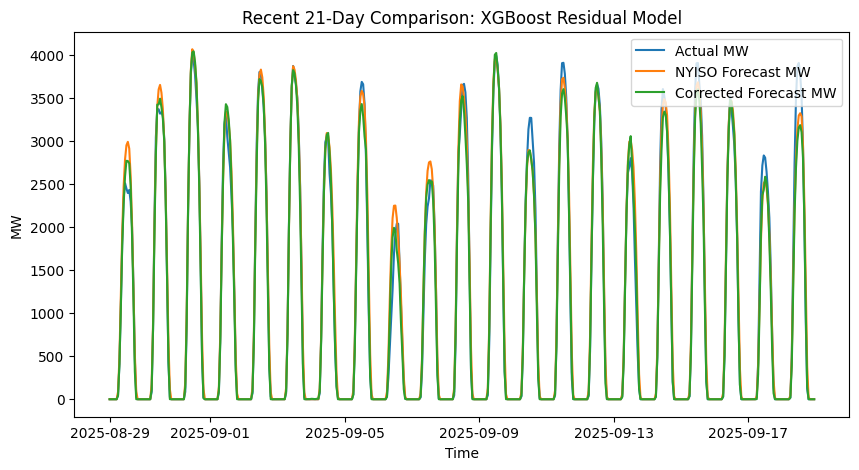

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(recent_plot["time_local"], recent_plot["actual_mw"], label="Actual MW")
plt.plot(recent_plot["time_local"], recent_plot["forecast_mw"], label="NYISO Forecast MW")
plt.plot(recent_plot["time_local"], recent_plot["corrected_forecast_mw"], label="Corrected Forecast MW")
plt.title(f"Recent 21-Day Comparison: {best_model_name}")
plt.xlabel("Time")
plt.ylabel("MW")
plt.legend()
plt.show()

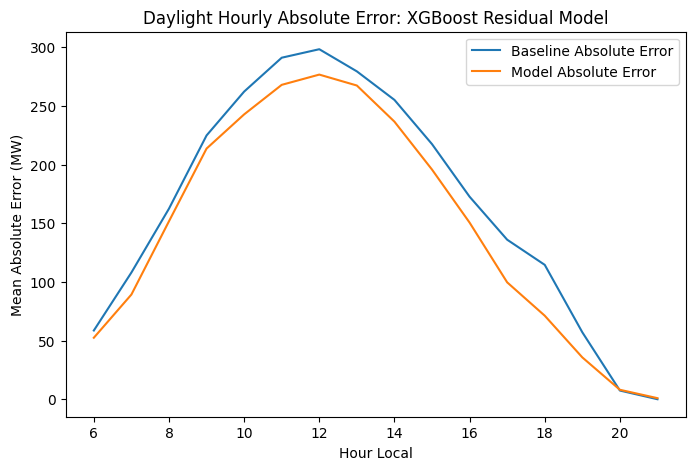

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(hourly_day["hour_local"], hourly_day["baseline_abs_error_mw"], label="Baseline Absolute Error")
plt.plot(hourly_day["hour_local"], hourly_day["model_abs_error_mw"], label="Model Absolute Error")
plt.title(f"Daylight Hourly Absolute Error: {best_model_name}")
plt.xlabel("Hour Local")
plt.ylabel("Mean Absolute Error (MW)")
plt.legend()
plt.show()

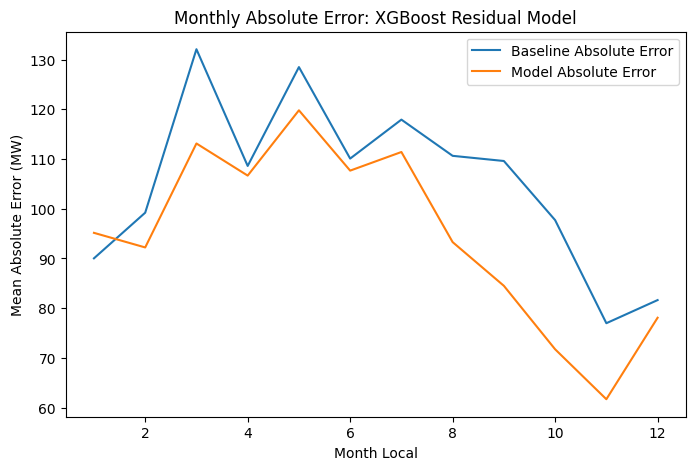

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(monthly_all["month_local"], monthly_all["baseline_abs_error_mw"], label="Baseline Absolute Error")
plt.plot(monthly_all["month_local"], monthly_all["model_abs_error_mw"], label="Model Absolute Error")
plt.title(f"Monthly Absolute Error: {best_model_name}")
plt.xlabel("Month Local")
plt.ylabel("Mean Absolute Error (MW)")
plt.legend()
plt.show()

## Findings for the Advanced Modeling Section

## Conclusion and Next Steps
c